<a href="https://colab.research.google.com/github/akash-g0807/Numerical-Analysis/blob/main/8_ODE_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

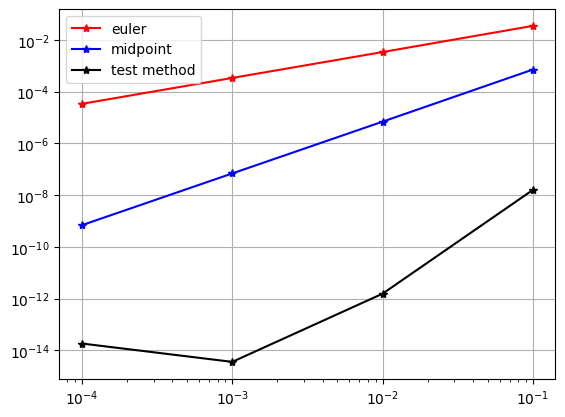

In [ ]:
def euler_1d(f, x0, t0, tmax, dt):
    # We need an integer number of steps so we round the number of steps
    # and then adjust dt to match.
    N = round((tmax - t0) / dt)
    dt = (tmax - t0) / N

    # Set up the time grid
    t = np.linspace(t0, tmax, N + 1)

    # Set up an array for x that is the same size as t
    x = np.zeros(len(t))

    # Fill in the initial condition
    x[0] = x0

    # Euler steps
    for n in range(N):
        x[n + 1] = x[n] + dt * f(t[n], x[n])

    return t, x

def midpoint_1d(f, x0, t0, tmax, dt):
    N = round((tmax - t0) / dt)
    dt = (tmax - t0) / N

    # build the times
    t = np.linspace(t0, tmax, N + 1)

    # build an array for x values
    x = np.zeros(len(t))

    # save the initial condition
    x[0] = x0

    # loop over time steps
    for n in range(N):
        # slope at current point
        slope = f(t[n], x[n])

        # half-step estimate
        x_halfstep = x[n] + (dt / 2) * slope

        # slope at midpoint and full step update
        x[n + 1] = x[n] + dt * f(t[n] + dt / 2, x_halfstep)

    return t, x

def ode_test(f, x0, t0, tmax, dt):
    N = round((tmax - t0)/dt)
    dt = (tmax - t0)/N
    t = np.linspace(t0, tmax, N+1) # set up the times
    x = np.zeros(len(t))            # set up the x
    x[0] = x0                       # initial condition
    for n in range(len(t)-1):
        m_n = f(t[n], x[n])
        x_n_plus_half = x[n] + dt/2 * m_n
        m_n_plus_half = f(t[n] + dt/2, x_n_plus_half)
        x_n_plus_half_star = x[n] + dt/2 * m_n_plus_half
        m_n_plus_half_star = f(t[n] + dt/2, x_n_plus_half_star)
        x_n_plus_1_star = x[n] + dt * m_n_plus_half_star
        m_n_plus_1_star = f(t[n] + dt, x_n_plus_1_star)
        estimate_of_slope = (1/6)*m_n + (2/6)*m_n_plus_half + (2/6)*m_n_plus_half_star + (1/6)*m_n_plus_1_star
        x[n+1] = x[n] + dt * estimate_of_slope
    return t, x


f = lambda t, x: -(1/3.0) * x + np.sin(t)
exact = lambda t: (1/10.0)*(19*np.exp(-t/3) + \
                  3*np.sin(t) - \
                  9*np.cos(t))

x0 = 1    # initial condition
t0 = 0    # initial time
tmax = 3  # max time
dt = 10.0**(-np.arange(1, 5, 1))
err_euler = np.zeros(len(dt))
err_midpoint = np.zeros(len(dt))
err_ode_test = np.zeros(len(dt))
for n in range(len(dt)):
    t, xeuler = euler_1d(f, x0, t0, tmax, dt[n])
    err_euler[n] = np.max(np.abs(xeuler - exact(t)))
    t, xmidpoint = midpoint_1d(f, x0, t0, tmax, dt[n])
    err_midpoint[n] = np.max(np.abs(xmidpoint - exact(t)))
    t, xtest = ode_test(f, x0, t0, tmax, dt[n])
    err_ode_test[n] = np.max(np.abs(xtest - exact(t)))

plt.loglog(dt, err_euler, 'r*-',
           dt, err_midpoint, 'b*-',
           dt, err_ode_test, 'k*-')
plt.grid()
plt.legend(['euler', 'midpoint', 'test method'])
plt.show()

In [ ]:
def rk4_1d(f, x0, t0, tmax, dt):
    N = round((tmax - t0)/dt)
    dt = (tmax - t0)/N
    t = np.linspace(t0, tmax, N+1)
    x = np.zeros(len(t))
    x[0] = x0
    for n in range(len(t)-1):
        k1 = f(t[n], x[n])
        k2 = f(t[n] + dt/2, x[n] + dt*k1/2)
        k3 = f(t[n] + dt/2, x[n] + dt*k2/2)
        k4 = f(t[n] + dt, x[n] + dt*k3)
        x[n+1] = x[n] + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)
    return t, x

In [ ]:
f = lambda t, x: -x/2+ np.sin(t)

x0 = 1  # initial condition
t0 = 0   # initial time
tmax = 10 # final time
dt = 1   # time step (your choice, but make it small)

t, x = rk4_1d(f, x0, t0, tmax, dt)

print(x[-1])

0.4651906180458938


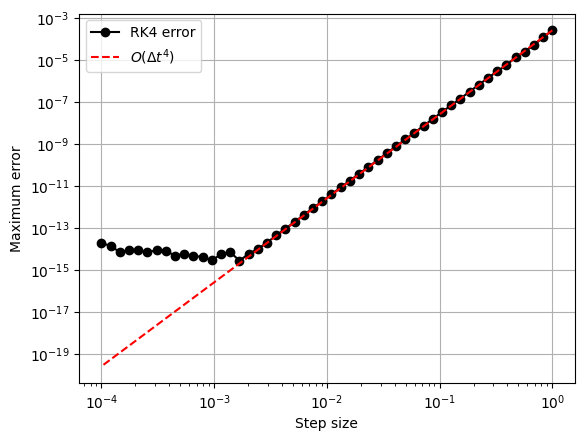

2.9066176446390393


In [ ]:
# ODE and exact solution
f = lambda t, x: -(1/3.0)*x + np.sin(t)
exact = lambda t: (1/10.0)*(19*np.exp(-t/3) + 3*np.sin(t) - 9*np.cos(t))

# Problem setup
x0 = 1
t0 = 0
tmax = 10

# Step sizes
dt = 10.0**(-np.linspace(0, 4, 50))
errors = np.zeros_like(dt)

# Compute max error for each step size
for i in range(len(dt)):
    t, x = rk4_1d(f, x0, t0, tmax, dt[i])
    errors[i] = np.max(np.abs(x - exact(t)))

# Log-log error plot
plt.loglog(dt, errors, 'ko-', label='RK4 error')
plt.xlabel('Step size')
plt.ylabel('Maximum error')
plt.grid()

# Reference O(dt^4) line
C = errors[0] / (dt[0]**4)
plt.loglog(dt, C*dt**4, 'r--', label=r'$O(\Delta t^4)$')

plt.legend()
plt.show()

m, b = np.polyfit(np.log(dt), np.log(errors), 1)
print(m)

In [ ]:
def rk4(F, x0, t0, tmax, dt):
    # We need an integer number of steps so we round the number of steps
    # and then adjust dt to match.
    N = round((tmax - t0) / dt)
    dt = (tmax - t0) / N

    # Set up the time grid
    t = np.linspace(t0, tmax, N + 1)

    # Set up an array for x with one row for each time step
    # and one column for each dependent variable
    x = np.zeros((len(t), len(x0)))

    # Store the initial condition in the first row of x
    x[0, :] = x0

    # Loop over the different time steps
    for n in range(N):
        k1 = F(t[n], x[n, :])
        k2 = F(t[n] + dt/2, x[n, :] + dt*k1/2)
        k3 = F(t[n] + dt/2, x[n, :] + dt*k2/2)
        k4 = F(t[n] + dt,   x[n, :] + dt*k3)

        x[n + 1, :] = x[n, :] + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)

    return t, x

In [ ]:
m = 2
b = 4
k = 128

F = lambda t, x: np.array([x[1], -(b/m)*x[1] - (k/m)*x[0]])

x0 = np.array([0.0, 0.6])   # [position, velocity]
t0 = 0
tmax = 5
dt = 0.1

t, x = rk4(F, x0, t0, tmax, dt)
print(x[-1, 0])
print(t,x)   # x(5)


0.0004884921930476946
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5
 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9 5. ] [[ 0.00000000e+00  6.00000000e-01]
 [ 4.86200000e-02  3.33160000e-01]
 [ 6.18738120e-02 -6.71571600e-02]
 [ 3.89421793e-02 -3.58175971e-01]
 [-1.08966960e-03 -4.00842512e-01]
 [-3.32632612e-02 -2.16923313e-01]
 [-4.14388652e-02  5.20574224e-02]
 [-2.55070928e-02  2.43813232e-01]
 [ 1.45991093e-03  2.67664545e-01]
 [ 2.27369931e-02  1.41053907e-01]
 [ 2.77400713e-02 -3.95945449e-02]
 [ 1.66903998e-02 -1.65849239e-01]
 [-1.46673654e-03 -1.78649193e-01]
 [-1.55286786e-02 -9.15912507e-02]
 [-1.85611832e-02  2.96762294e-02]
 [-1.09097916e-02  1.12738992e-01]
 [ 1.30965912e-03  1.19179838e-01]
 [ 1.05970017e-02  5.93845245e-02]
 [ 1.24137085e-02 -2.19832166e-02]
 [ 7.12339358e-03 -7.65856949e-02]
 [-1.09614648e-03 -7.94683524e-02]
 [-7.22588790e-03 -3.84413653e-02]


In [ ]:
def secant(f, x_nm1, x_n, tol=1e-10, max_iter=5):

    print(x_nm1)
    print(x_n)
    for _ in range(max_iter):

        f_nm1 = f(x_nm1)
        f_n = f(x_n)

        denominator = f_n - f_nm1
        if denominator == 0:
            raise ZeroDivisionError("Secant method failed: denominator is zero.")

        # Secant update
        x_np1 = x_n - f_n * (x_n - x_nm1) / denominator

        # Check convergence
        if abs(x_np1 - x_n) < tol:
            return x_np1

        # Shift indices
        x_nm1, x_n = x_n, x_np1

    return "Method did not converge"

def backward_euler_1d(f, x0, t0, tmax, dt):
    N = round((tmax - t0)/dt)
    dt = (tmax - t0)/N
    t = np.linspace(t0, tmax, N+1)
    x = np.zeros(len(t))
    x[0] = x0

    for n in range(len(t)-1):
        G = lambda y: y - dt*f(t[n+1], y) - x[n]
        x[n+1] = secant(G, x[n], x[n] + dt*f(t[n], x[n]))

    return t, x

In [ ]:
import numpy as np

f = lambda t, x: -x/2 + np.sin(t)

t, x = backward_euler_1d(f, 1, 0, 10, 1)

print(x[-1])

1.0
0.5
1.2276473232052643
1.4552946464105285
1.424629833353964
1.6216123435026637
1.0438332276092208
0.6630366218644776
0.1913538215341952
-0.6611255845408306
-0.5117136354192955
-1.2147810923727862
-0.5274194224121476
-0.5431252094049996
0.08637811753776103
0.7001756574876695
0.7171575761074286
1.3479370346770962
0.7528507075661234
0.7885438390248183
0.13921973111783573


1.0
0.9666666666666667
0.9774032338690479
0.9548064677380959
0.9651001615631168
0.9527970892571858
0.9625666279637911
0.9600330943644654
0.9692017376077318
0.9758368472516724
0.9843331852917601
0.9994646329757884
1.0072233219012228
1.0301134585106855
1.0370758941532179
1.066928466405213
1.073043390235326
1.1090108863174342
1.1142349172884591
1.1554264443415923
1.1597245313895956
1.2052141454907321
1.208559936189425
1.2573953409892544
1.259771462696272
1.3109829892031188
1.3123812399077335
1.364991017119195
1.3654124641031415
1.4184436882985496
1.4178986736421422
1.4703848831811428
1.4688929360770575
1.5198871985119728
1.5174768552796494
1.5660607744822412
1.5627693080975504
1.6080617609154515
1.6039348227738308
1.6451003374501112
1.6401915149578055
1.6764482071417801
1.6708185015703478
1.7014454881828902
1.6951627180183615
1.7195069344663751
1.7126450702284195
1.7301274224384775
1.722765859629227
1.7328866490300345
1.7251094264899574
1.7274529933506877
1.7193479648439713
1.713586503197

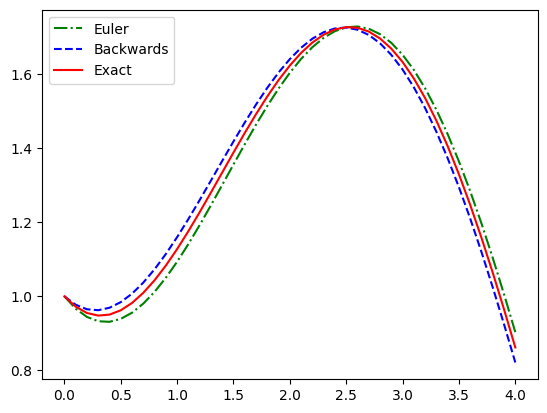

In [ ]:
f = lambda t, x: -x/3+np.sin(t)
x_exact = lambda t: (19*np.exp(-t/3)+3*np.sin(t)-9*np.cos(t)) / 10
x0 = 1
t0 = 0
tmax = 4
dt = 0.1
t, x_euler = euler_1d(f,x0,t0,tmax,dt)
t, x_backward = backward_euler_1d(f,x0,t0,tmax,dt)
plt.plot(t, x_euler, 'g-.', label = "Euler")
plt.plot(t, x_backward, 'b--', label = "Backwards")
plt.plot(t, x_exact(t), 'r-', label = "Exact")
plt.legend()

1.0
-1.5
0.2857142857142857
-0.4285714285714285
0.08163265306122448
-0.12244897959183672
0.02332361516034985
-0.034985422740524776
0.006663890045814243
-0.009995835068721363
0.001903968584518355
-0.0028559528767775322
0.0005439910241481014
-0.0008159865362221523
0.00015542600689945755
-0.00023313901034918632


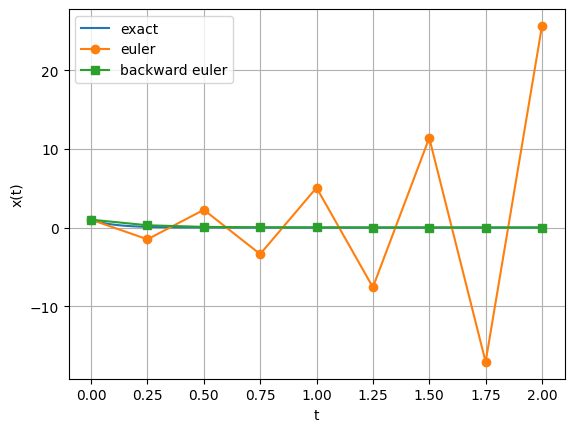

In [ ]:
# ODE and exact solution
f = lambda t, x: -10*x
exact = lambda t: np.exp(-10*t)

# setup
x0 = 1
t0 = 0
tmax = 2
dt = 0.25   # try 0.5 also

# numerical solutions using your existing functions
t_e, x_e = euler_1d(f, x0, t0, tmax, dt)
t_b, x_b = backward_euler_1d(f, x0, t0, tmax, dt)

# exact solution
t_exact = np.linspace(t0, tmax, 400)
x_exact = exact(t_exact)

# plot
plt.plot(t_exact, x_exact, label='exact')
plt.plot(t_e, x_e, 'o-', label='euler')
plt.plot(t_b, x_b, 's-', label='backward euler')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.grid()
plt.legend()
plt.show()

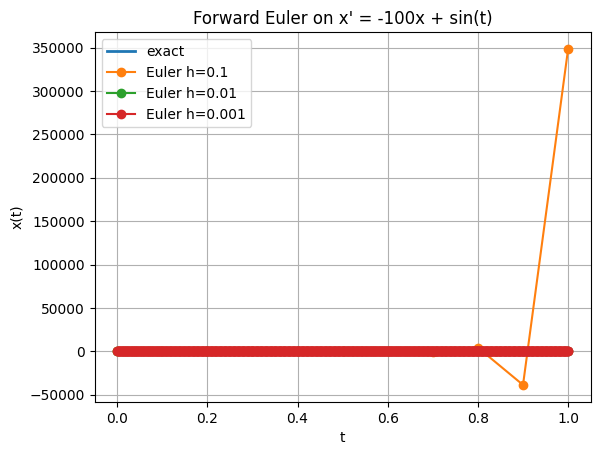

0.0
0.0


ZeroDivisionError: Secant method failed: denominator is zero.

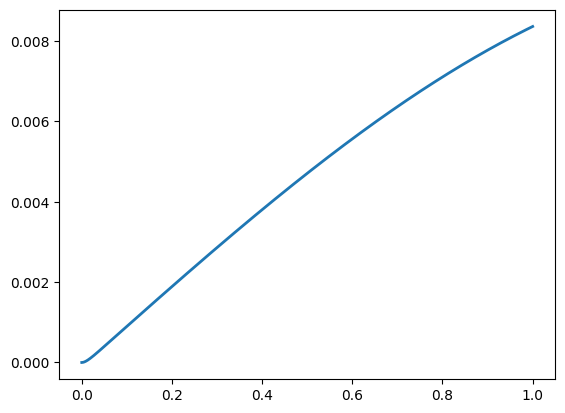

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# problem
f = lambda t, x: -100*x + np.sin(t)
exact = lambda t: (1/10001)*(np.exp(-100*t) + 100*np.sin(t) - np.cos(t))

x0 = 0
t0 = 0
tmax = 1

# step sizes
hs = [0.1, 0.01, 0.001]

# exact curve
t_exact = np.linspace(t0, tmax, 2000)
x_exact = exact(t_exact)

# -------------------------
# (a) Forward Euler
# -------------------------
plt.figure()
plt.plot(t_exact, x_exact, label='exact', linewidth=2)

for h in hs:
    t, x = euler_1d(f, x0, t0, tmax, h)
    plt.plot(t, x, 'o-', label=f'Euler h={h}')

plt.xlabel('t')
plt.ylabel('x(t)')
plt.title("Forward Euler on x' = -100x + sin(t)")
plt.grid()
plt.legend()
plt.show()

# -------------------------
# (b) Backward Euler
# -------------------------
plt.figure()
plt.plot(t_exact, x_exact, label='exact', linewidth=2)

for h in hs:
    t, x = backward_euler_1d(f, x0, t0, tmax, h)
    plt.plot(t, x, 'o-', label=f'Backward Euler h={h}')

plt.xlabel('t')
plt.ylabel('x(t)')
plt.title("Backward Euler on x' = -100x + sin(t)")
plt.grid()
plt.legend()
plt.show()

# -------------------------
# (c) RK4
# -------------------------
plt.figure()
plt.plot(t_exact, x_exact, label='exact', linewidth=2)

for h in hs:
    t, x = rk4_1d(f, x0, t0, tmax, h)
    plt.plot(t, x, 'o-', label=f'RK4 h={h}')

plt.xlabel('t')
plt.ylabel('x(t)')
plt.title("RK4 on x' = -100x + sin(t)")
plt.grid()
plt.legend()
plt.show()

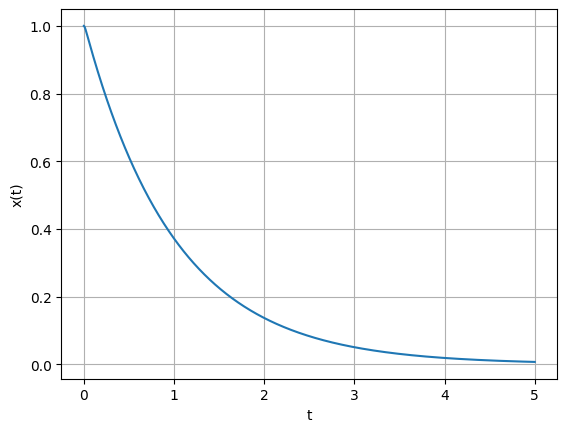

In [ ]:
gamma = 100
x = lambda t: (gamma/(gamma-1))*np.exp(-t) - (1/(gamma-1))*np.exp(-gamma*t)

t = np.linspace(0, 5, 1000)
plt.plot(t, x(t))
plt.xlabel('t')
plt.ylabel('x(t)')
plt.grid()
plt.show()

In [ ]:
import numpy as np
from scipy import optimize

def backward_euler(F,x0,t0,tmax,dt):
    N = round((tmax - t0)/dt)
    dt = (tmax - t0)/N
    t = np.linspace(t0, tmax, N+1)
    x = np.zeros((len(t), len(x0)))
    x[0,:] = x0
    for n in range(len(t)-1):
        # G takes a vector y and returns a vector
        G = lambda y: y - dt*F(t[n+1],y) - x[n,:]
        # fsolve with initial guess as the previous time step's vector
        x[n+1,:] = optimize.fsolve(G, x[n,:])
    return t, x